# Préprocessing — AI4I 2020 (visualisé étape par étape)

Traitement des problèmes identifiés dans l'EDA (`eda_ai4i_2020.ipynb`) :

| Problème EDA | Traitement ici | Visualisation |
|---|---|---|
| Outliers `Rotational speed [rpm]` / `Torque [Nm]` | **Capping doux** aux quantiles `[0.5 %, 99.5 %]` — aucune ligne supprimée (les extrêmes concentrent les PWF = du signal !) | boxplots + histos avant/après |
| Corrélation `Air ↔ Process temperature` (**r = 0.876**) | Dérivation `temperature_delta_k` puis suppression de `Process temperature [K]` | heatmap avant/après |
| Anti-corrélation `RPM ↔ Torque` (**r = −0.875**) | Dérivation physique `puissance_w = Torque × ω` (définition même du mode PWF) puis suppression de `Torque [Nm]` | heatmap avant/après + distributions par classe |
| Déséquilibre 3,39 % | ❌ **PAS ici** — traité à l'entraînement via `--balance-class-weights` | — |

> Ces transformations existent aussi dans le code production
> (`gmao_ml/data/feature_engineering.py :: SensorFeatureEngineer`) et sont
> **embarquées dans le pipeline sérialisé** : à l'inférence, l'API reçoit les
> capteurs bruts et applique elle-même capping/dérivations/suppressions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
sns.set_theme(style="whitegrid", palette="deep")

SAVE_FIGURES = True
TARGET = "machine_failure"

CAP_COLS = ["Rotational speed [rpm]", "Torque [Nm]"]
CAP_QUANTILES = (0.005, 0.995)

AIR_COL = "Air temperature [K]"
PROCESS_COL = "Process temperature [K]"
TORQUE_COL = "Torque [Nm]"
RPM_COL = "Rotational speed [rpm]"

DELTA_TEMP = "temperature_delta_k"
PUISSANCE = "puissance_w"

DROP_AFTER_DERIVE = [PROCESS_COL, TORQUE_COL]

NUM_BEFORE = [AIR_COL, PROCESS_COL, RPM_COL, TORQUE_COL, "Tool wear [min]"]


def locate_project_dir() -> Path:
    """Remonte depuis le CWD jusqu'à trouver le dossier GMAO-ML/."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if candidate.name == "GMAO-ML":
            return candidate
        if (candidate / "GMAO-ML" / "data").is_dir():
            return candidate / "GMAO-ML"
        if (candidate / "data" / "ai4i_2020.csv").is_file():
            return candidate
    raise FileNotFoundError("Dossier GMAO-ML/ introuvable depuis " + str(Path.cwd()))


PROJECT_DIR = locate_project_dir()
DATA_PATH = PROJECT_DIR / "data" / "ai4i_2020.csv"
REPORTS_DIR = PROJECT_DIR / "data" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(REPORTS_DIR / f"{name}.png", dpi=120, bbox_inches="tight")


df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset brut : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")

Dataset brut : 10000 lignes × 13 colonnes


## 0. État initial — rappel des corrélations problématiques

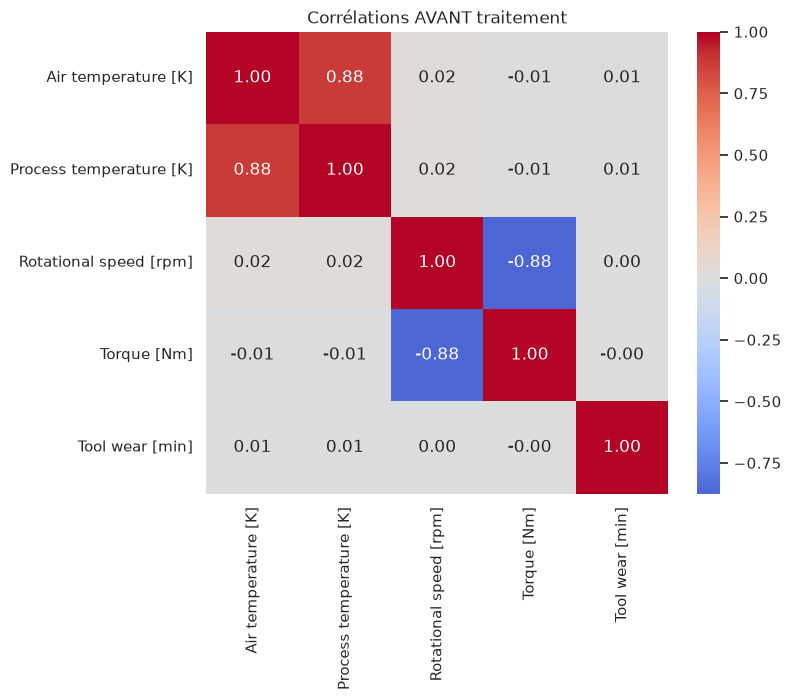

Nombre de paires avec |r| > 0.5 : 2
Max |r|                         : 0.876
Air temperature [K]     Process temperature [K]    0.8760
Rotational speed [rpm]  Torque [Nm]               -0.8750


In [2]:
corr_before = df_raw[NUM_BEFORE].corr(method="pearson")

upper = corr_before.where(np.triu(np.ones(corr_before.shape), k=1).astype(bool)).stack()
strong_before = upper[abs(upper) > 0.5]
max_r_before = float(upper.abs().max())

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr_before, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Corrélations AVANT traitement")
save_fig(fig, "10_corr_avant")
plt.show()

print(f"Nombre de paires avec |r| > 0.5 : {len(strong_before)}")
print(f"Max |r|                         : {max_r_before:.3f}")
print(strong_before.round(3).to_string())

## 1. Capping doux des outliers (`Rotational speed`, `Torque`)

Bornes apprises aux quantiles `[0.5 %, 99.5 %]`. On **ne supprime aucune ligne** :
on vérifie ci-dessous que les valeurs plafonnées concentrent une part importante
des défaillances (zone PWF) — les supprimer reviendrait à jeter le signal.

In [3]:
cap_bounds = {
    col: tuple(df_raw[col].quantile(list(CAP_QUANTILES)))
    for col in CAP_COLS
}

rows_outliers = pd.Series(False, index=df_raw.index)
for col, (low, high) in cap_bounds.items():
    rows_outliers |= ~df_raw[col].between(low, high)

report = pd.DataFrame({
    "borne_basse": [round(cap_bounds[c][0], 2) for c in CAP_COLS],
    "borne_haute": [round(cap_bounds[c][1], 2) for c in CAP_COLS],
    "n_valeurs_plafonnees": [
        int((~df_raw[c].between(*cap_bounds[c])).sum()) for c in CAP_COLS
    ],
}, index=CAP_COLS)
display(report)

taux_global = df_raw[TARGET].mean() * 100
taux_outliers = df_raw.loc[rows_outliers, TARGET].mean() * 100
print(f"Taux de défaillance GLOBAL          : {taux_global:.2f} %")
print(f"Taux de défaillance parmi plafonnés : {taux_outliers:.2f} % "
      f"({int(rows_outliers.sum())} lignes concernées)")
if taux_outliers > taux_global * 2:
    print("-> Confirmation : les valeurs extrêmes sont un SIGNAL (bien plus de pannes).")
    print("   D'où le choix d'un capping (conserve les lignes) plutôt qu'une suppression.")

,borne_basse,borne_haute,n_valeurs_plafonnees
Rotational speed [rpm],1255.9900,2372.0200,100
Torque [Nm],14.5000,65.9000,100


Taux de défaillance GLOBAL          : 3.39 %
Taux de défaillance parmi plafonnés : 54.29 % (140 lignes concernées)
-> Confirmation : les valeurs extrêmes sont un SIGNAL (bien plus de pannes).
   D'où le choix d'un capping (conserve les lignes) plutôt qu'une suppression.


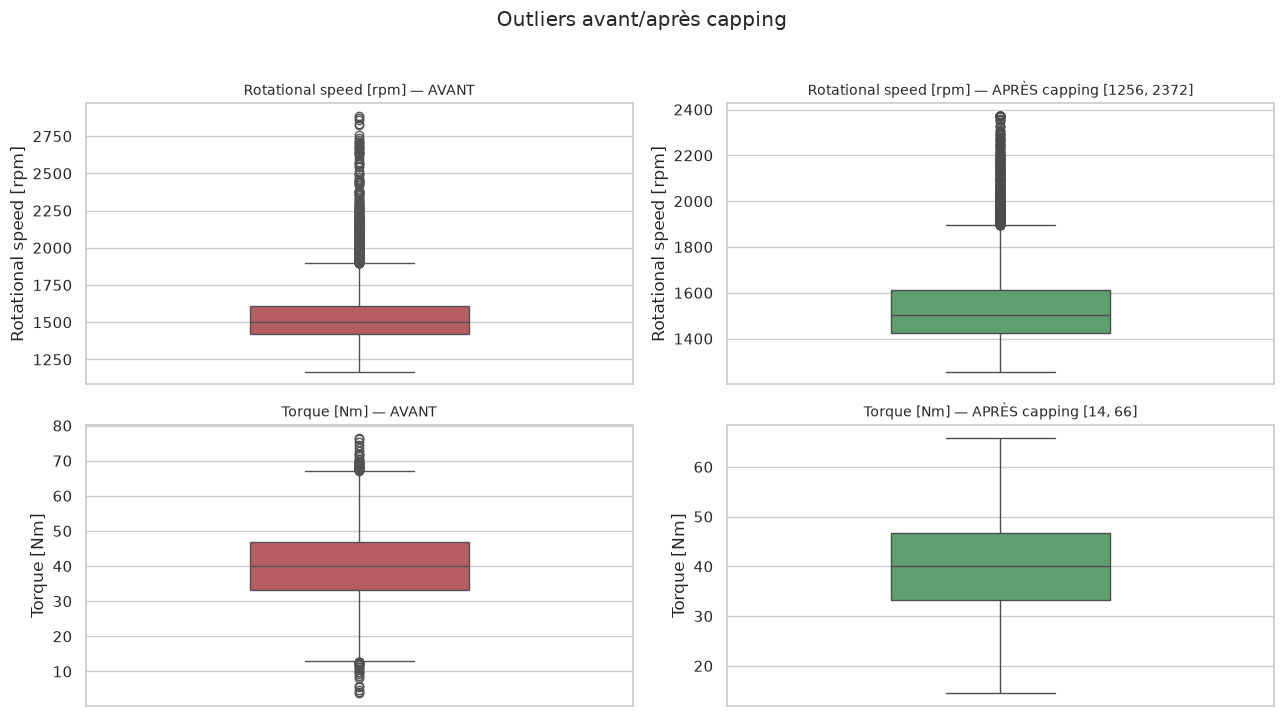

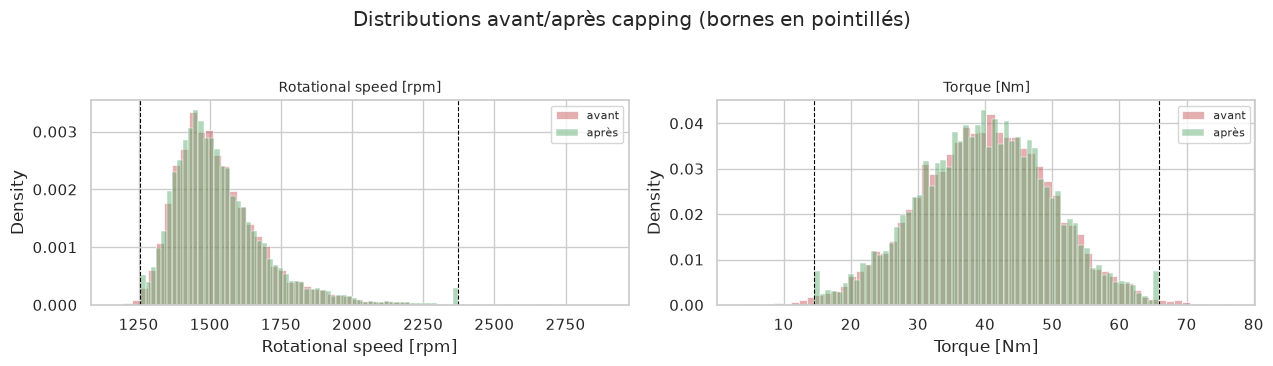

Après étape 1 : 10000 lignes × 13 colonnes


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for row, col in enumerate(CAP_COLS):
    low, high = cap_bounds[col]

    sns.boxplot(y=df_raw[col], ax=axes[row, 0], color="#C44E52", width=0.4)
    axes[row, 0].set_title(f"{col} — AVANT", fontsize=10)

    capped_preview = df_raw[col].clip(lower=low, upper=high)
    sns.boxplot(y=capped_preview, ax=axes[row, 1], color="#55A868", width=0.4)
    axes[row, 1].set_title(f"{col} — APRÈS capping [{low:.0f}, {high:.0f}]", fontsize=10)

fig.suptitle("Outliers avant/après capping", y=1.02)
fig.tight_layout()
save_fig(fig, "11_boxplots_capping")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, col in zip(axes, CAP_COLS):
    low, high = cap_bounds[col]
    sns.histplot(df_raw[col], bins=60, ax=ax, color="#C44E52", alpha=0.45,
                 stat="density", label="avant")
    sns.histplot(df_raw[col].clip(lower=low, upper=high), bins=60, ax=ax,
                 color="#55A868", alpha=0.45, stat="density", label="après")
    ax.axvline(low, color="black", linestyle="--", linewidth=0.8)
    ax.axvline(high, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Distributions avant/après capping (bornes en pointillés)", y=1.04)
fig.tight_layout()
save_fig(fig, "12_histos_capping")
plt.show()

df_step1 = df_raw.copy()
for col, (low, high) in cap_bounds.items():
    df_step1[col] = df_step1[col].clip(lower=low, upper=high)
print(f"Après étape 1 : {df_step1.shape[0]} lignes × {df_step1.shape[1]} colonnes")

## 2. Features dérivées physiquement

- `temperature_delta_k = Process − Air` : échauffement net du procédé (mode HDF) ;
- `puissance_w = Torque × ω` avec `ω = RPM × 2π/60` : puissance mécanique —
  la définition littérale du mode de défaillance **PWF** (plage ±20 W autour de 250 W).

In [5]:
df_step2 = df_step1.copy()

df_step2[DELTA_TEMP] = df_step2[PROCESS_COL] - df_step2[AIR_COL]
omega_rad_s = df_step2[RPM_COL] * (2.0 * np.pi / 60.0)
df_step2[PUISSANCE] = df_step2[TORQUE_COL] * omega_rad_s

print(df_step2[[DELTA_TEMP, PUISSANCE]].describe().loc[["mean", "std", "min", "max"]])

      temperature_delta_k  puissance_w
mean              10.0006    6280.5973
std                1.0011    1055.6119
min                7.6000    3449.5630
max               12.1000    9700.9240


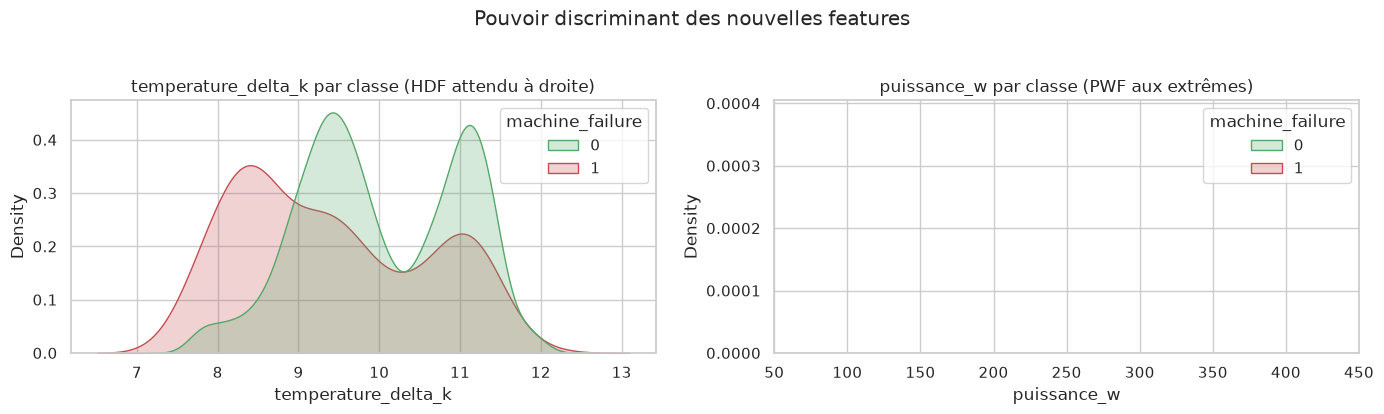

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=df_step2, x=DELTA_TEMP, hue=TARGET, common_norm=False,
            fill=True, palette=["#55A868", "#C44E52"], ax=axes[0])
axes[0].set_title(f"{DELTA_TEMP} par classe (HDF attendu à droite)")

sns.kdeplot(data=df_step2, x=PUISSANCE, hue=TARGET, common_norm=False,
            fill=True, palette=["#55A868", "#C44E52"], ax=axes[1])
axes[1].set_xlim(50, 450)
axes[1].set_title(f"{PUISSANCE} par classe (PWF aux extrêmes)")

fig.suptitle("Pouvoir discriminant des nouvelles features", y=1.03)
fig.tight_layout()
save_fig(fig, "13_features_derivees")
plt.show()

## 3. Suppression des originaux devenus redondants

Une fois `temperature_delta_k` et `puissance_w` créées :

- `Process temperature [K]` est retirée (info conservée par `Air temp` + delta) ;
- `Torque [Nm]` est retiré (info conservée par `RPM` + puissance).

La corrélation n'est pas magiquement effacée : elle est **partiellement transférée** aux dérivées (`Air ↔ delta` ≈ −0.70, `RPM ↔ puissance` ≈ −0.81), car une dérivée hérite mathématiquement de son dominateur. C'est acceptable :
- les **arbres** (RF/HGB) sont insensibles à la multicolinéarité pour la prédiction ;
- la **régression logistique** est régularisée (`C=1`) ;
- les features restantes portent un **sens physique** direct (delta, puissance).

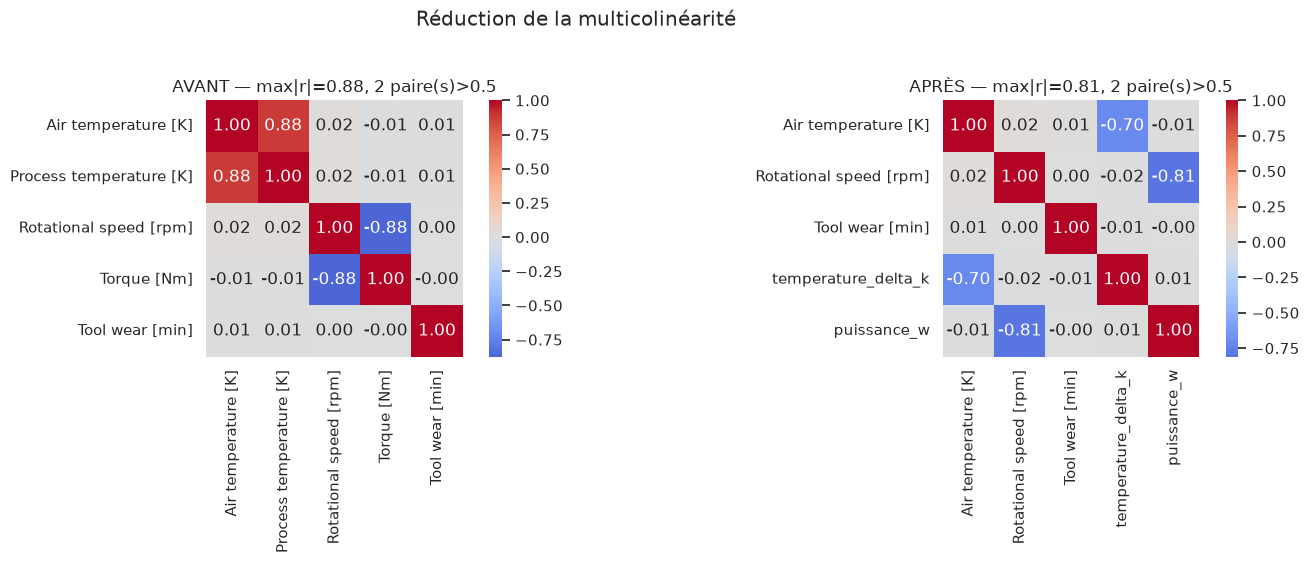

Paires fortes (>0.5) : 2 -> 2
Max |r|              : 0.876 -> 0.811
Air temperature [K]     temperature_delta_k   -0.7000
Rotational speed [rpm]  puissance_w           -0.8110


In [7]:
df_prepared = df_step2.drop(columns=DROP_AFTER_DERIVE)

num_after = ["Air temperature [K]", RPM_COL, "Tool wear [min]", DELTA_TEMP, PUISSANCE]
corr_after = df_prepared[num_after].corr(method="pearson")

upper_a = corr_after.where(np.triu(np.ones(corr_after.shape), k=1).astype(bool)).stack()
strong_after = upper_a[abs(upper_a) > 0.5]
max_r_after = float(upper_a.abs().max())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(corr_before, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=axes[0])
axes[0].set_title(f"AVANT — max|r|={max_r_before:.2f}, {len(strong_before)} paire(s)>0.5")
sns.heatmap(corr_after, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=axes[1])
axes[1].set_title(f"APRÈS — max|r|={max_r_after:.2f}, {len(strong_after)} paire(s)>0.5")

fig.suptitle("Réduction de la multicolinéarité", y=1.02)
fig.tight_layout()
save_fig(fig, "14_corr_avant_apres")
plt.show()

print("=" * 58)
print(f"Paires fortes (>0.5) : {len(strong_before)} -> {len(strong_after)}")
print(f"Max |r|              : {max_r_before:.3f} -> {max_r_after:.3f}")
print("=" * 58)
if strong_after.empty:
    print("[OK] Plus aucune redondance forte entre variables conservées.")
else:
    print(strong_after.round(3).to_string())

## 4. Export du dataset préparé

Le fichier sert au **suivi/comparaison** ; pour l'entraînement réel il est
recommandé d'utiliser le CSV brut : le pipeline sérialisé embarque ces mêmes
transformations (`SensorFeatureEngineer`), activées par défaut dans `train.py`.

In [8]:
out_path = PROJECT_DIR / "data" / "ai4i_2020_prepared.csv"
df_prepared.to_csv(out_path, index=False)

print(f"Écrit : {out_path}")
print(f"Shape finale : {df_prepared.shape[0]} lignes × {df_prepared.shape[1]} colonnes")
print(f"Colonnes     : {list(df_prepared.columns)}")
display(df_prepared.head())

Écrit : /home/abdellah-daif/Gmao-Services-IA/GMAO-ML/data/ai4i_2020_prepared.csv
Shape finale : 10000 lignes × 13 colonnes
Colonnes     : ['Type', 'Air temperature [K]', 'Rotational speed [rpm]', 'Tool wear [min]', 'machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'failure_type', 'temperature_delta_k', 'puissance_w']


,Type,Air temperature [K],Rotational speed [rpm],Tool wear [min],machine_failure,TWF,HDF,PWF,OSF,RNF,failure_type,temperature_delta_k,puissance_w
0,M,298.1000,1551.0000,0,0,0,0,0,0,0,No Failure,10.5000,6951.5906
1,L,298.2000,1408.0000,3,0,0,0,0,0,0,No Failure,10.5000,6826.7227
2,L,298.1000,1498.0000,5,0,0,0,0,0,0,No Failure,10.4000,7749.3875
3,L,298.2000,1433.0000,7,0,0,0,0,0,0,No Failure,10.4000,5927.5047
4,L,298.2000,1408.0000,9,0,0,0,0,0,0,No Failure,10.5000,5897.8166


## 5. Synthèse

In [9]:
lines = [
    "=" * 62,
    "SYNTHÈSE DU PREPROCESSING",
    "=" * 62,
    f"Lignes                       : {df_raw.shape[0]} (aucune supprimée)",
    "",
    "1. CAPPING OUTLIERS (quantiles %.1f%%/%.1f%%)" % tuple(q*100 for q in CAP_QUANTILES),
]
for col, (low, high) in cap_bounds.items():
    lines.append(f"   - {col:<24}: [{low:,.0f} ; {high:,.0f}]".replace(",", " "))
lines += [
    f"     signal vérifié : taux de panne parmi valeurs plafonnées = {taux_outliers:.1f}% "
    f"(vs {taux_global:.1f}% global) -> capping, pas suppression",
    "",
    "2. FEATURES DERIVEES",
    f"   - {DELTA_TEMP} = Process − Air (échauffement net, mode HDF)",
    f"   - {PUISSANCE} = Torque × ω (puissance mécanique, mode PWF)",
    "",
    "3. REDONDANCES SUPPRIMEES",
    f"   - Colonnes retirées : {', '.join(DROP_AFTER_DERIVE)}",
    f"   - Multicolinéarité  : {len(strong_before)} -> {len(strong_after)} paire(s) |r|>0.5"
     f" (max |r| {max_r_before:.3f} -> {max_r_after:.3f})",
    "     NB : corrélation partiellement TRANSFEREE aux dérivées (attendu) —"
    "",
    f"4. EXPORT : data/ai4i_2020_prepared.csv ({df_prepared.shape[0]}×{df_prepared.shape[1]})",
    "",
    "NON TRAITE ICI : déséquilibre des classes -> --balance-class-weights à l'entraînement.",
    "=" * 62,
]
print("\n".join(lines))

SYNTHÈSE DU PREPROCESSING
Lignes                       : 10000 (aucune supprimée)

1. CAPPING OUTLIERS (quantiles 0.5%/99.5%)
   - Rotational speed [rpm]  : [1 256 ; 2 372]
   - Torque [Nm]             : [14 ; 66]
     signal vérifié : taux de panne parmi valeurs plafonnées = 54.3% (vs 3.4% global) -> capping, pas suppression

2. FEATURES DERIVEES
   - temperature_delta_k = Process − Air (échauffement net, mode HDF)
   - puissance_w = Torque × ω (puissance mécanique, mode PWF)

3. REDONDANCES SUPPRIMEES
   - Colonnes retirées : Process temperature [K], Torque [Nm]
   - Multicolinéarité  : 2 -> 2 paire(s) |r|>0.5 (max |r| 0.876 -> 0.811)
     NB : corrélation partiellement TRANSFEREE aux dérivées (attendu) —
4. EXPORT : data/ai4i_2020_prepared.csv (10000×13)

NON TRAITE ICI : déséquilibre des classes -> --balance-class-weights à l'entraînement.
